# Sheet 01 - Regression & Classification

Introduction to Deep Learning - Summer Semester 2026

Ulf Krumnack & Robin Rawiel - Universität OsnabrückDue: April 19, 2026

## Task 1: Theory Questions \[6 points\]

### 1.1 Loss Functions \[2 points\]

1.  Define the **Mean Squared Error (MSE)** loss function. For a dataset
    $\{(x_i, y_i)\}_{i=1}^{N}$ and a model $f_\theta$, write down the
    MSE loss $\mathcal{L}(\theta)$.

    ---

    $$
        \mathcal{L}(\theta) = \frac{1}{2n}\sum_{i=1}^{n} (y_i - (b + wx_i))^2
    $$

<!-- -->

2.  Write down the **binary cross-entropy** loss for a single sample
    $(x, y)$ where $y \in \{0, 1\}$ and
    $\hat{y} = \sigma(\theta^\top x)$ is the predicted probability.

    ---

    For a single sample $(x, y)$ where the true label $y \in \{0, 1\}$ and the predicted probability is $\hat{y} = \sigma(\theta^\top x)$, the **binary cross-entropy (BCE) loss** (also known as log loss) is defined as:

    $$ L(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right] $$

    $\hat{y} = \sigma(\theta^\top x)$ - predicted value formula where:
    * $\hat{y}$ : predicted value
    * $\sigma$ : the sigmoid (logistic) function
    * $x$ : input data value
    * $\theta^\top$ : optimal parameters for the model (weights vector)

    By substituting the prediction function $\hat{y} = \sigma(\theta^\top x)$ directly into the equation, we can express the loss in terms of the model weights $\theta$ and the input features $x$:

    $$ L(y, x, \theta) = - \left[ y \log(\sigma(\theta^\top x)) + (1 - y) \log(1 - \sigma(\theta^\top x)) \right] $$

<!-- -->

3.  Consider the **Mean Absolute Error (MAE)** loss
    $\mathcal{L} = \frac{1}{N}\sum_i |y_i - f_\theta(x_i)|$. Compare it
    to MSE:
    - Which loss is more sensitive to outliers? Justify your answer.
    - Which loss is differentiable everywhere? Why does this matter for
      gradient-based optimization?

    > **Hint**
    >
    > The MAE penalises errors *linearly* — each residual
    > $|y_i - f_\theta(x_i)|$ contributes proportionally to its magnitude —
    > whereas MSE penalises errors *quadratically*. Think about what
    > squaring does to large vs. small residuals.

    ---

    **Which loss is more sensitive to outliers? Justify your answer**

    MSE squares errors, large errors have a disproportionaletly big impact making MSE more sensitive to ouliers. In contrast MAE just taeks the absolute value, so each error contributes linearly, making it less sensitive to those big outliers

    **Which loss is differentiable everywhere? Why does this matter for gradient-based optimization?**

    Mean absolute error has a sharp corner at zero. This matters because in gradient-based optimization we use gradient to guide steps. If gradient is defined everytwhere the optimization is smooth. But if not the optimization can get stuck or take awkward steps.
    

    <details>
    <summary><em>Additional personal learning context</em></summary>

    **Outliers**

    A data point that is significantly different from the other points in the dataset — a rare event that does not fit the general pattern of the data.

    **Mean Absolute Error (MAE)**

    *Advantages:*
    - Less sensitive to outliers (more robust)
    - Easier to interpret (error is in original units)

    *Disadvantages:*
    - Not differentiable at zero
    - Does not heavily penalize large errors
    - Less sensitive to small deviations

    **Mean Squared Error (MSE)**

    *Advantages:*
    - Heavily penalizes large errors
    - Fully differentiable at every point
    - Nice mathematical structure:
      - Smooth, continuous curve
      - Easy to optimize with gradient descent

    *Disadvantages:*
    - Very sensitive to outliers
    - Harder to interpret (error is not in original units)

    </details>

### 1.2 Maximum Likelihood Estimation \[2 points\]

1.  Assume the data-generating process is
    $y = f_\theta(x) + \varepsilon$ where
    $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. Show that maximizing
    the log-likelihood of the data under this model is equivalent to
    minimizing the squared error loss.

    ---

    **What is $\varepsilon$?**

    The model says: true value = prediction + noise, i.e. $y = f_\theta(x) + \varepsilon$

    - $y$ — the real, observed value
    - $f_\theta(x)$ — what the model predicts
    - $\varepsilon$ — the gap between them; random noise from measurement error, missing variables, or natural randomness

    We assume this noise is Gaussian: $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, meaning it is centered at zero (no systematic bias) and has a spread of $\sigma^2$.

    ---

    **1. Gaussian probability of one observation**

    Since $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, the probability of observing $y_i$ given $x_i$ is:

    $$p(y_i \mid x_i, \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - f_\theta(x_i))^2}{2\sigma^2}\right)$$

    **2. Likelihood over the full dataset**

    For $N$ independent observations, multiply the individual probabilities:

    $$\mathcal{L}(\theta) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - f_\theta(x_i))^2}{2\sigma^2}\right)$$

    **3. Log-likelihood — turn products into sums**

    $$\log \mathcal{L}(\theta) = \sum_{i=1}^{N} \left[ -\tfrac{1}{2}\log(2\pi\sigma^2) - \frac{(y_i - f_\theta(x_i))^2}{2\sigma^2} \right]$$

    **4. Drop constants**

    The first term $-\tfrac{N}{2}\log(2\pi\sigma^2)$ does not depend on $\theta$, so maximizing $\log\mathcal{L}$ is the same as:

    $$\arg\max_\theta \; \left[ -\frac{1}{2\sigma^2} \sum_{i=1}^{N}(y_i - f_\theta(x_i))^2 \right]$$

    **5. Flip max → min**

    Because of the leading $-$, maximizing the expression is equivalent to minimizing the sum:

    $$\arg\min_\theta \; \sum_{i=1}^{N}(y_i - f_\theta(x_i))^2 \quad \equiv \quad \arg\min_\theta \; \mathcal{L}_{\text{MSE}}(\theta) \quad \blacksquare$$

<!-- -->

1.  Now assume $\varepsilon$ follows a **Laplace distribution**
    $p(\varepsilon) = \frac{1}{2b}\exp\!\bigl(-\frac{|\varepsilon|}{b}\bigr)$.
    Which loss function does maximum likelihood estimation correspond to
    in this case?

    > **Hint**
    >
    > Follow the same log-likelihood derivation strategy as in 1.2.1: write
    > down $p(y_i \mid x_i, \theta)$ under the Laplace noise assumption,
    > take the log, and identify which terms depend on $\theta$. Compare the
    > result to the MAE formula from 1.1.3.

    ---

    **What is $\varepsilon$ here?**

    Same idea as before: $y = f_\theta(x) + \varepsilon$, so $\varepsilon = y - f_\theta(x)$ is the noise. This time we assume it follows a **Laplace distribution** instead of a Gaussian — meaning large errors are still possible, but they are penalised *linearly*, not quadratically. $b > 0$ is a fixed scale constant (analogous to $\sigma$).

    **1. Laplace probability of one observation**

    Substituting $\varepsilon = y_i - f_\theta(x_i)$ into the Laplace PDF:

    $$p(y_i \mid x_i, \theta) = \frac{1}{2b} \exp\!\left(-\frac{|y_i - f_\theta(x_i)|}{b}\right)$$

    **2. Likelihood over the full dataset**

    $$\mathcal{L}(\theta) = \prod_{i=1}^{N} \frac{1}{2b} \exp\!\left(-\frac{|y_i - f_\theta(x_i)|}{b}\right)$$

    **3. Log-likelihood — turn products into sums**

    $$\log \mathcal{L}(\theta) = \sum_{i=1}^{N} \left[ -\log(2b) - \frac{|y_i - f_\theta(x_i)|}{b} \right]$$

    **4. Drop constants**

    $-N\log(2b)$ does not depend on $\theta$, and $\frac{1}{b}$ is a fixed positive scale, so maximizing $\log\mathcal{L}$ is the same as:

    $$\arg\max_\theta \; \left[ -\frac{1}{b} \sum_{i=1}^{N} |y_i - f_\theta(x_i)| \right]$$

    **5. Flip max → min**

    $$\arg\min_\theta \; \sum_{i=1}^{N} |y_i - f_\theta(x_i)| \quad \equiv \quad \arg\min_\theta \; \mathcal{L}_{\text{MAE}}(\theta) \quad \blacksquare$$

    MLE under **Laplace noise** corresponds to minimizing **MAE**.

### 1.3 Softmax & Evaluation \[2 points\]

1.  Write down the **softmax function** mapping a logit vector
    $z \in \mathbb{R}^K$ to a probability vector. Show that
    $\text{softmax}(z) = \text{softmax}(z - c)$ for any constant $c$ and
    explain why this is useful for numerical implementation.

    ---

    **Softmax function**

    For a logit vector $z \in \mathbb{R}^K$, the softmax of the $k$-th element is:

    $$\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

    It maps any real-valued vector to a valid probability distribution: all outputs are in $(0, 1)$ and sum to 1.

    **Proof: $\text{softmax}(z) = \text{softmax}(z - c)$**

    $$\text{softmax}(z - c)_k = \frac{e^{z_k - c}}{\sum_{j=1}^{K} e^{z_j - c}} = \frac{e^{z_k} \cdot e^{-c}}{\sum_{j=1}^{K} e^{z_j} \cdot e^{-c}} = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}} = \text{softmax}(z)_k \quad \blacksquare$$

    **Why this matters numerically**

    $e^{z_k}$ overflows to `inf` when $z_k$ is large (e.g. 1000). By subtracting $c = \max(z)$, the largest exponent becomes $e^0 = 1$ and all others are $\leq 1$, so no overflow occurs — and the result is mathematically identical.

<!-- -->

1.  Define **accuracy**, **precision**, and **recall** using the entries
    of the confusion matrix (TP, TN, FP, FN). When is accuracy a
    misleading metric?

    ---

    **Confusion matrix entries**

    | | Predicted Positive | Predicted Negative |
    |---|---|---|
    | **Actually Positive** | TP (True Positive) | FN (False Negative) |
    | **Actually Negative** | FP (False Positive) | TN (True Negative) |

    **Formulas**

    $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

    $$\text{Precision} = \frac{TP}{TP + FP}$$

    $$\text{Recall} = \frac{TP}{TP + FN}$$

    - **Precision** — of all the samples we *predicted* positive, how many actually were?
    - **Recall** — of all the samples that *actually* were positive, how many did we catch?

    **When is accuracy misleading?**

    When the dataset is **class-imbalanced**. For example, if 95% of samples are negative, a model that always predicts "negative" achieves 95% accuracy — yet it never finds a single positive case. Precision and recall expose this failure; accuracy hides it.

## Task 2: Linear Regression with PyTorch \[6 points\]

**Learning objectives:**

- Get familiar with PyTorch tensors and basic linear algebra operations
- Implement the closed-form (normal equation) solution for linear
  regression
- Visualize data and the fitted regression line

<details>
<summary><em>Additional personal learning context: PyTorch</em></summary>

**What is PyTorch?**

A Python library for numerical computation built around **tensors** — the core data structure. Think of a tensor as a generalized array:
- scalar → 0D tensor (a single number)
- vector → 1D tensor `[1, 2, 3]`
- matrix → 2D tensor
- image batch → 4D tensor `(batch, channels, height, width)`

**Why PyTorch instead of NumPy?**

| | NumPy | PyTorch |
|---|---|---|
| Runs on GPU | No | Yes (`tensor.to('cuda')`) |
| Tracks gradients | No | Yes (`requires_grad=True`) |
| Used for deep learning | Rarely | Standard |

**Three things you will use constantly**

```python
torch.manual_seed(42)        # makes random results reproducible
torch.randn(N)               # N random numbers from N(0,1)
torch.ones(N, 1)             # column of ones (used for bias term)
```

**Gradient tracking** is what makes PyTorch special. When you set `requires_grad=True`, PyTorch silently records every operation so it can automatically compute derivatives later — that's how gradient descent works without you doing the calculus by hand.

</details>

### 2.1 Generate Synthetic Data \[1 point\]

Generate $N = 100$ data points from the model $y = 3x + 2 + \varepsilon$
where $\varepsilon \sim \mathcal{N}(0, 1)$ using PyTorch tensors. Plot
the data.

<details>
<summary><em>Additional personal learning context: generating data in PyTorch</em></summary>

### Reproducibility — always set the seed first

```python
torch.manual_seed(42)   # any integer; guarantees identical results every run
```

Without this, `torch.randn` and friends produce different numbers each time, so your plots and model weights will drift between runs.

---

### Tensor shapes matter

Every PyTorch tensor has a `.shape` (a `torch.Size` object). For 1-D data:

```python
x = torch.randn(100)   # shape: (100,)  — a flat vector of 100 numbers
```

For matrix operations you often need a **column vector**:

```python
x = torch.randn(100, 1)   # shape: (100, 1)  — 100 rows, 1 column
```

You can convert between the two:

```python
x = x.reshape(-1, 1)   # flatten any shape → column vector
x = x.squeeze()        # remove dimensions of size 1 → back to (100,)
```

---

### Generating random numbers

PyTorch has two main functions:

| Function | Distribution | Typical use |
|---|---|---|
| `torch.rand(N)` | Uniform $[0, 1)$ | Random fractions, dropout masks |
| `torch.randn(N)` | Standard normal $\mathcal{N}(0,1)$ | Noise, weight initialisation |

To shift or scale the output, just apply arithmetic:

```python
torch.rand(N) * (b - a) + a       # uniform in [a, b]
torch.randn(N) * std + mean        # normal with custom mean and std
torch.randn(N) * 0.5               # N(0, 0.25) — half the spread
```

---

### Other useful tensor creation functions

```python
torch.linspace(start, end, steps)  # evenly-spaced values (great for x-axes)
torch.arange(start, end, step)     # like Python range(), returns a tensor
torch.zeros(N)                     # all zeros
torch.ones(N)                      # all ones
torch.full((N,), fill_value)       # constant tensor
```

Example — a clean grid of 200 x-values from −3 to 3:

```python
x = torch.linspace(-3, 3, 200)    # shape: (200,)
```

---

### Building a synthetic dataset step-by-step

Synthetic data is generated from a **known** formula so you can verify your model recovers the right parameters. The general pattern:

```
x   = generate inputs
y   = apply formula(x)  +  add noise
```

For this task, $y = 3x + 2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$:

```python
torch.manual_seed(42)

N       = 100
x       = torch.randn(N)           # inputs drawn from N(0,1)
epsilon = torch.randn(N)           # noise term ε ~ N(0,1)
y       = 3 * x + 2 + epsilon      # true relationship + noise
```

> **Why `torch.randn` for x here?**  
> Inputs drawn from $\mathcal{N}(0,1)$ are centred, which makes the
> normal equation numerically well-behaved. You could equally use
> `torch.linspace(-3, 3, N)` if you prefer evenly-spaced inputs.

---

### Tensor arithmetic is element-wise

PyTorch tensors support Python operators out of the box:

```python
y = 3 * x + 2 + epsilon   # each element of x is multiplied/added individually
```

You can also use named functions for clarity:

```python
y = torch.add(torch.mul(x, 3), 2) + epsilon   # identical result
```

---

### Inspecting your tensors (good habit)

Before plotting, always sanity-check shape, type, and value range:

```python
print(x.shape)    # torch.Size([100])
print(x.dtype)    # torch.float32
print(x.min(), x.max())          # rough range
print(x.mean(), x.std())         # should be ≈ 0 and ≈ 1 for randn
```

---

### Plotting with matplotlib

```python
plt.scatter(x, y, alpha=0.6)    # alpha makes overlapping points visible
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data: y = 3x + 2 + ε")
plt.show()
```

Matplotlib usually works directly with PyTorch tensors. If you see an error like *"can't convert cuda:0 device type tensor"*, add `.numpy()` or `.detach().numpy()`:

```python
plt.scatter(x.numpy(), y.numpy())
```

> **`.detach()` vs `.numpy()`**  
> If your tensor has `requires_grad=True` (gradient tracking on), you
> must call `.detach()` first to "detach" it from the computation graph
> before converting to NumPy. For plain data tensors (no gradients),
> `.numpy()` alone is fine.

</details>

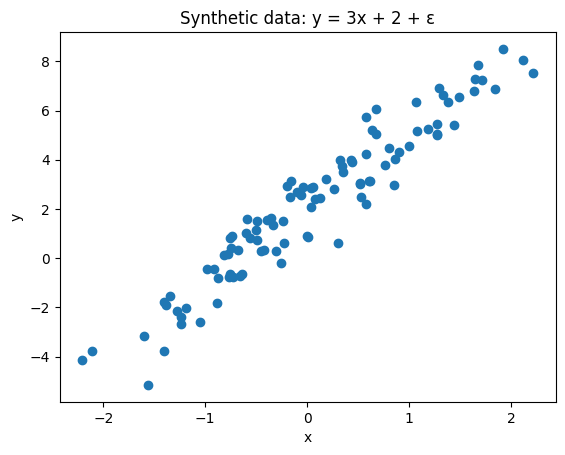

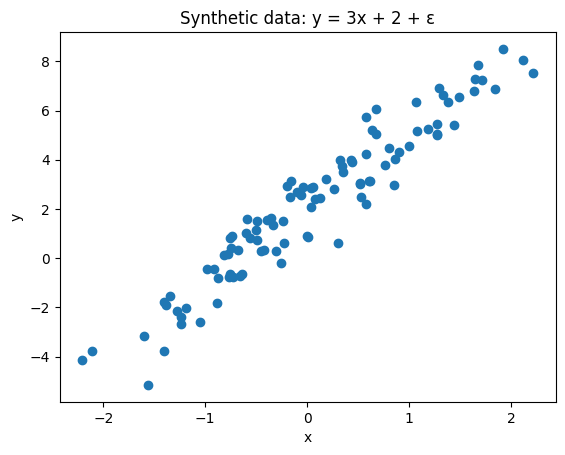

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

# TODO: Your solution here

# Generate N = 100 data point from the model y = 3x + 2 + epsilon
N = 100
xTensor = torch.randn(N)
epsilonTensor = torch.randn(N)
yTensor = 3 * xTensor + 2 + epsilonTensor

# Put data on the plot
title = "Synthetic data: y = 3x + 2 + ε"

## Using scatter
plt.scatter(xTensor, yTensor)
plt.title(title)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Using plot
plt.plot(xTensor, yTensor, "o")
plt.title(title)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### 2.2 Closed-Form Solution \[3 points\]

Implement the **normal equation** $\theta = (X^\top X)^{-1} X^\top y$
using PyTorch tensor operations to find the optimal parameters $[w, b]$.

<details>
<summary><em>Additional personal learning context: normal equation</em></summary>

Sources: [Breathe Math – Deriving the Normal Equation (analytic)](https://www.youtube.com/watch?v=1kkVEcmhkL8) · [Joseph Gonzalez – Deriving the Normal Equation (geometric)](https://www.youtube.com/watch?v=zkJ3CULN8Wk)

---

### Setup — matrix notation

Before deriving anything, rewrite the problem in compact matrix form.

Define:
- **Design matrix** $X \in \mathbb{R}^{N \times 2}$ — each row is $[x_i,\ 1]$ (the 1 carries the bias):

$$X = \begin{bmatrix} x_1 & 1 \\ x_2 & 1 \\ \vdots & \vdots \\ x_N & 1 \end{bmatrix}$$

- **Parameter vector** $\theta = [w,\ b]^\top \in \mathbb{R}^2$
- **Target vector** $y = [y_1,\ y_2,\ \ldots,\ y_N]^\top \in \mathbb{R}^N$

Then $X\theta = \hat{y}$ — all $N$ predictions at once.

The **squared loss** becomes:

$$\mathcal{L}(\theta) = \|y - X\theta\|^2 = (y - X\theta)^\top (y - X\theta)$$

(uses the identity $\|q\|^2 = q^\top q$)

---

### Proof 1 — Analytic (calculus) derivation

*From [Breathe Math](https://www.youtube.com/watch?v=1kkVEcmhkL8)*

**Step 1 — Write the loss as a vector squared magnitude**

$$\mathcal{L}(\theta) = \|y - X\theta\|^2$$

A squared vector magnitude equals the vector times its own transpose:

$$\mathcal{L}(\theta) = (y - X\theta)^\top (y - X\theta)$$

**Step 2 — Expand the product**

Multiply out like a binomial $(a - b)^\top(a - b)$ with $a = y$, $b = X\theta$:

$$\mathcal{L}(\theta) = y^\top y \;-\; y^\top X\theta \;-\; \theta^\top X^\top y \;+\; \theta^\top X^\top X\,\theta$$

Both middle terms are scalars and equal (a scalar equals its own transpose: $y^\top X\theta = \theta^\top X^\top y$), so they combine:

$$\mathcal{L}(\theta) = y^\top y \;-\; 2\,\theta^\top X^\top y \;+\; \theta^\top X^\top X\,\theta$$

**Step 3 — Differentiate term by term w.r.t. $\theta$**

Three matrix calculus rules used here:

| Term | Rule | Result |
|---|---|---|
| $y^\top y$ | constant w.r.t. $\theta$ | $0$ |
| $\theta^\top X^\top y$ | $\frac{\partial}{\partial\theta}(\theta^\top a) = a$ | $X^\top y$ |
| $\theta^\top X^\top X\,\theta$ | $\frac{\partial}{\partial\theta}(\theta^\top A\theta) = 2A\theta$ (A symmetric) | $2\,X^\top X\,\theta$ |

Putting it together:

$$\frac{\partial \mathcal{L}}{\partial \theta} = 0 - 2\,X^\top y + 2\,X^\top X\,\theta$$

**Step 4 — Set to zero and solve**

$$2\,X^\top X\,\theta - 2\,X^\top y = 0$$

$$X^\top X\,\theta = X^\top y$$

Multiply both sides on the left by $(X^\top X)^{-1}$:

$$\boxed{\theta = (X^\top X)^{-1} X^\top y}$$

> **Why $(X^\top X)^{-1}$ and not $X^{-1}$?**  
> $X$ is rarely square ($N \gg 2$), so it has no inverse. But $X^\top X$ is always $2 \times 2$ here and invertible as long as the columns of $X$ are linearly independent (i.e. the data is not degenerate).

---

### Proof 2 — Geometric derivation

*From [Joseph Gonzalez](https://www.youtube.com/watch?v=zkJ3CULN8Wk)*

**Key insight: $\hat{y} = X\theta$ lives in a subspace**

$\hat{y}$ is a *linear combination* of the columns of $X$:

$$\hat{y} = X\theta = \theta_1 \cdot \underbrace{x_{\cdot 1}}_{\text{col 1 of }X} + \theta_2 \cdot \underbrace{x_{\cdot 2}}_{\text{col 2 of }X}$$

No matter what $\theta$ you choose, $\hat{y}$ is always confined to the **column space** of $X$ — a 2-D plane inside $\mathbb{R}^N$.

The true $y$, however, can be *anywhere* in $\mathbb{R}^N$.

```
          y  (observed — anywhere in ℝᴺ)
          ↑
          |  ← residual r = y − ŷ
          |
──────────●──────── column space of X  (the plane)
          ŷ = Xθ̂  (our best prediction, on the plane)
```

**Minimise the residual by making it perpendicular to the plane**

The shortest path from $y$ to any point on the plane is the **perpendicular drop**. So the optimal $\hat{\theta}$ is the one where:

$$r = y - X\hat\theta \perp \text{col}(X)$$

Orthogonality means the dot product of $r$ with every column of $X$ is zero:

$$X^\top (y - X\hat\theta) = 0$$

**Expand and solve — same final step as before**

$$X^\top y - X^\top X\,\hat\theta = 0 \implies \boxed{\hat\theta = (X^\top X)^{-1} X^\top y}$$

Both proofs arrive at the same equation via completely different routes — calculus and geometry are just two languages describing the same truth.

---

### Summary

| | Analytic proof | Geometric proof |
|---|---|---|
| **Starting point** | Differentiate $\mathcal{L}$, set $= 0$ | Residual must be $\perp$ to col$(X)$ |
| **Key step** | Matrix calculus | Orthogonality condition |
| **Result** | $X^\top X\,\theta = X^\top y$ | $X^\top X\,\theta = X^\top y$ |

---

### PyTorch implementation

```python
ones  = torch.ones(N, 1)
X     = torch.cat([x.unsqueeze(1), ones], dim=1)   # (N, 2) design matrix

# Direct formula
theta = torch.linalg.inv(X.T @ X) @ X.T @ y        # [w, b]

# Numerically safer alternative (avoids explicit inversion)
theta, _, _, _ = torch.linalg.lstsq(X, y)
```

`theta[0]` → slope $w$, `theta[1]` → intercept $b$.

</details>

In [30]:
def closed_form_solution(x, y):
    """Compute optimal [slope, intercept] via the normal equation.

    Args:
        x: Input features, shape (N,)
        y: Targets, shape (N,)

    Returns:
        theta: Tensor [slope, intercept]
    """
    # TODO: Your solution here

### 2.3 Visualize the Fit \[2 points\]

Plot the data points together with the fitted regression line. Also plot
the true line $y = 3x + 2$ for comparison.

In [ ]:
# TODO: Your solution here

## Task 3: Logistic Regression with PyTorch \[8 points\]

**Learning objectives:**

- Implement sigmoid and binary cross-entropy using PyTorch tensors
- Train a binary classifier using gradient descent
- Visualize decision boundaries

### 3.1 Activation Functions \[1 point\]

Implement numerically stable versions of sigmoid and softmax using
PyTorch.

> **Hint: Numerical stability of sigmoid**
>
> The naïve formula $\sigma(z) = \frac{1}{1 + e^{-z}}$ can overflow when
> $z$ is a large negative number (because $e^{-z}$ explodes). An
> equivalent form $\sigma(z) = \frac{e^{z}}{1 + e^{z}}$ is safe for
> $z < 0$ but overflows for large positive $z$. Use `torch.where` to
> pick the appropriate formula depending on the sign of $z$.

In [ ]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


def sigmoid(z):
    """Numerically stable sigmoid function.

    Args:
        z: Input tensor.

    Returns:
        Tensor of same shape with values in (0, 1).
    """
    # TODO: Your solution here


def softmax(z):
    """Numerically stable softmax. z has shape (N, K).

    Args:
        z: Input tensor, shape (N, K).

    Returns:
        Tensor of same shape, rows sum to 1.
    """
    # TODO: Your solution here

### 3.2 Data and Loss \[2 points\]

Generate the moons dataset and implement binary cross-entropy.

In [ ]:
# Generate data
X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="bwr", alpha=0.6)
plt.title("Moons Dataset (Train)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

In [ ]:
def binary_cross_entropy(y_true, y_pred):
    """Compute the mean binary cross-entropy loss.

    Args:
        y_true: True labels, shape (N,), values in {0, 1}.
        y_pred: Predicted probabilities, shape (N,), values in (0, 1).

    Returns:
        Scalar loss.
    """
    # TODO: Your solution here

### 3.3 Training \[2 points\]

Implement logistic regression training with gradient descent.

In [ ]:
def logistic_regression_train(X_train, y_train, lr=0.1, n_iterations=1000):
    """Train binary logistic regression using gradient descent.

    Args:
        X_train: Training features, shape (N, D).
        y_train: Training labels, shape (N,).
        lr: Learning rate.
        n_iterations: Number of gradient descent steps.

    Returns:
        w: Weights, shape (D,).
        b: Bias (scalar tensor).
        losses: List of loss values per iteration.
    """
    # TODO: Your solution here

In [ ]:
# TODO: Your solution here

### 3.4 Evaluate and Visualize \[2 points\]

Compute accuracy on train and test sets. Plot the decision boundary.

In [ ]:
def predict(X, w, b, threshold=0.5):
    """Predict class labels."""
    # TODO: Your solution here


def plot_decision_boundary(X, y, w, b):
    """Plot data points and the linear decision boundary."""
    # TODO: Your solution here

In [ ]:
# TODO: Your solution here

### 3.5 Reflection \[1 point\]

1.  Why can logistic regression not perfectly separate the moons
    dataset?
2.  What would you change to achieve a better fit?